In [49]:
# Imports & Setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

print(" Libraries imported successfully")


 Libraries imported successfully


In [50]:
# Load Dataset
file_path = r"C:\Users\Muhammad Ali\Desktop\Devs Hub\household_power_consumption.csv"

df = pd.read_csv(
    file_path,
    sep=None,
    engine="python"
)

df.columns = df.columns.str.strip()

print("Dataset loaded")
print("Columns:", list(df.columns))
print("Shape:", df.shape)


Dataset loaded
Columns: ['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
Shape: (1048575, 9)


In [52]:
# Datetime Parsing
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    dayfirst=True,
    errors="coerce"
)

df.set_index("Datetime", inplace=True)

print(" Datetime created and set as index")
print(df.index.min(), "→", df.index.max())


 Datetime created and set as index
2006-12-16 17:24:00 → 2008-12-13 21:38:00


In [54]:
# Target Cleaning
df["Global_active_power"] = pd.to_numeric(
    df["Global_active_power"], errors="coerce"
)

df.dropna(subset=["Global_active_power"], inplace=True)

print(" Target column cleaned")
print("Remaining rows:", len(df))


 Target column cleaned
Remaining rows: 1044506


In [56]:
# Hourly Resampling
ts = df["Global_active_power"].resample("h").mean()
ts = ts.dropna()

print(" Resampled to hourly data")
print("Total hourly records:", len(ts))
ts.head()


 Resampled to hourly data
Total hourly records: 17415


Datetime
2006-12-16 17:00:00    4.222889
2006-12-16 18:00:00    3.632200
2006-12-16 19:00:00    3.400233
2006-12-16 20:00:00    3.268567
2006-12-16 21:00:00    3.056467
Name: Global_active_power, dtype: float64

In [60]:
# Train / Test Split
split = int(len(ts) * 0.8)

train = ts.iloc[:split]
test = ts.iloc[split:]

print(" Train-test split completed")
print("Train size:", len(train))
print("Test size:", len(test))


 Train-test split completed
Train size: 13932
Test size: 3483


In [61]:
# ARIMA Model
arima_model = ARIMA(train, order=(1, 1, 1))
arima_fit = arima_model.fit()
arima_forecast = arima_fit.forecast(len(test))

print(" ARIMA model trained")
print("ARIMA forecast sample:")
arima_forecast.head()


 ARIMA model trained
ARIMA forecast sample:


13932    0.453489
13933    0.570853
13934    0.652027
13935    0.708170
13936    0.747002
Name: predicted_mean, dtype: float64

In [63]:
# Prophet model
prophet_df = ts.reset_index()
prophet_df.columns = ["ds", "y"]

prophet = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False
)

prophet.fit(prophet_df.iloc[:split])

future = prophet.make_future_dataframe(
    periods=len(test),
    freq="h"
)

forecast = prophet.predict(future)
prophet_forecast = forecast["yhat"].iloc[split:].values

print(" Prophet model trained")
print("Prophet forecast sample:", prophet_forecast[:5])


15:46:41 - cmdstanpy - INFO - Chain [1] start processing
15:46:44 - cmdstanpy - INFO - Chain [1] done processing


 Prophet model trained
Prophet forecast sample: [1.45150633 1.68781075 1.54882385 1.11965478 0.64291641]


In [65]:
# XGBoost Model
xgb_df = ts.reset_index()
xgb_df.columns = ["Datetime", "power"]

xgb_df["hour"] = xgb_df["Datetime"].dt.hour
xgb_df["weekday"] = xgb_df["Datetime"].dt.weekday
xgb_df["is_weekend"] = (xgb_df["weekday"] >= 5).astype(int)

X = xgb_df[["hour", "weekday", "is_weekend"]]
y = xgb_df["power"]

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    objective="reg:squarederror",
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_forecast = xgb.predict(X_test)

print(" XGBoost model trained")
print("XGBoost forecast sample:", xgb_forecast[:5])


 XGBoost model trained
XGBoost forecast sample: [1.7018359  1.9563679  1.989233   1.4741594  0.93941826]


In [67]:
# Model Evaluation
def evaluate(name, actual, pred):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    print(f"{name} -> MAE: {mae:.3f}, RMSE: {rmse:.3f}")

print(" MODEL PERFORMANCE")
evaluate("ARIMA", test.values, arima_forecast.values)
evaluate("Prophet", test.values, prophet_forecast)
evaluate("XGBoost", y_test.values, xgb_forecast)


 MODEL PERFORMANCE
ARIMA -> MAE: 0.690, RMSE: 0.903
Prophet -> MAE: 0.707, RMSE: 0.941
XGBoost -> MAE: 0.620, RMSE: 0.822


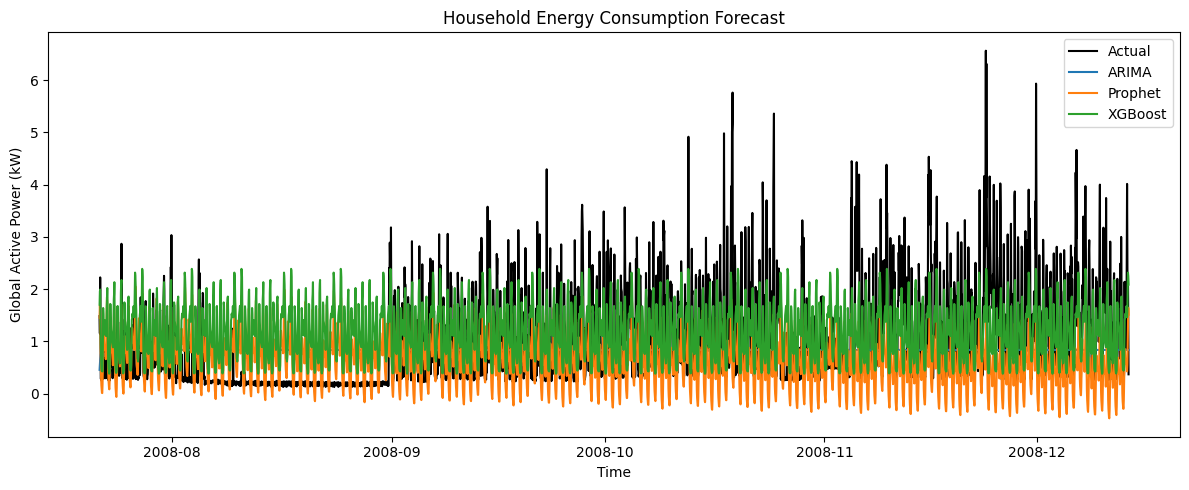

 Plot displayed successfully


In [69]:
# Visualization
plt.figure(figsize=(12, 5))
plt.plot(test.index, test.values, label="Actual", color="black")
plt.plot(test.index, arima_forecast, label="ARIMA")
plt.plot(test.index, prophet_forecast, label="Prophet")
plt.plot(test.index, xgb_forecast, label="XGBoost")

plt.title("Household Energy Consumption Forecast")
plt.xlabel("Time")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.tight_layout()
plt.show()

print(" Plot displayed successfully")


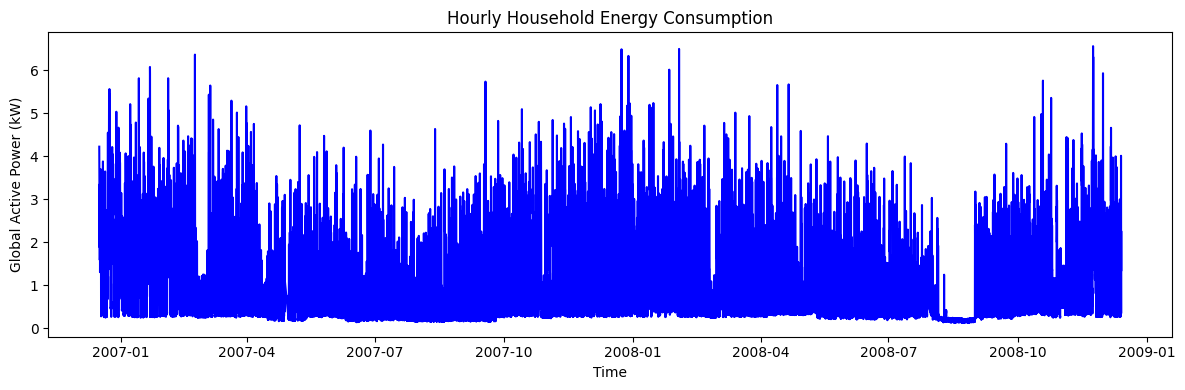

In [70]:
plt.figure(figsize=(12,4))
plt.plot(ts.index, ts.values, color="blue")
plt.title("Hourly Household Energy Consumption")
plt.xlabel("Time")
plt.ylabel("Global Active Power (kW)")
plt.tight_layout()
plt.show()


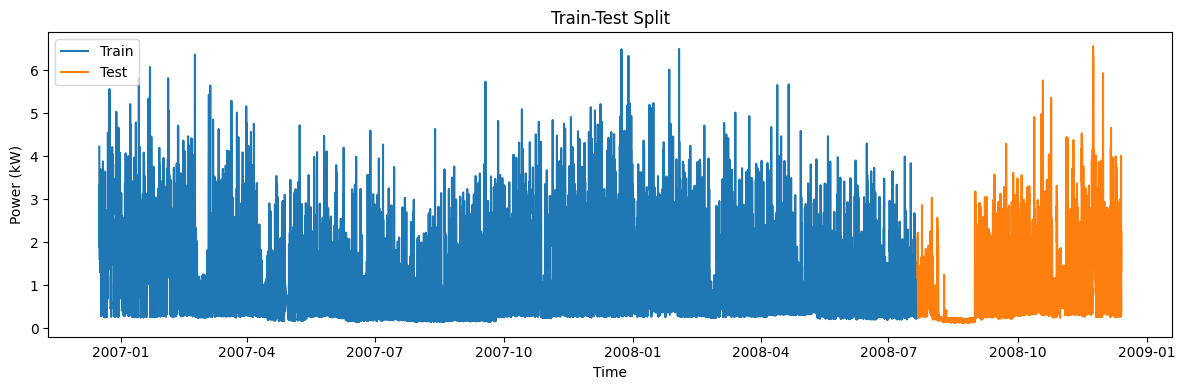

In [71]:
plt.figure(figsize=(12,4))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.title("Train-Test Split")
plt.xlabel("Time")
plt.ylabel("Power (kW)")
plt.legend()
plt.tight_layout()
plt.show()
